In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
df = pd.read_csv("../data/Afficionado Coffee Roasters.xlsx - Transactions (1).csv")

# Feature Engineering
df["Revenue"] = df["transaction_qty"] * df["unit_price"]

df["transaction_time"] = pd.to_datetime(df["transaction_time"], format="%H:%M:%S")

df["Hour"] = df["transaction_time"].dt.hour

def time_bucket(hour):
    if 6 <= hour <= 11:
        return "Morning"
    elif 12 <= hour <= 16:
        return "Afternoon"
    elif 17 <= hour <= 21:
        return "Evening"
    else:
        return "Late Hours"

df["Time Bucket"] = df["Hour"].apply(time_bucket)

In [4]:
print("="*50)
print("BUSINESS SUMMARY")
print("="*50)

print(f"Total Revenue : ${df['Revenue'].sum():,.2f}")
print(f"Total Transactions : {df['transaction_id'].count():,}")
print(f"Total Quantity Sold : {df['transaction_qty'].sum():,}")
print(f"Average Order Value : ${df['Revenue'].mean():.2f}")

BUSINESS SUMMARY
Total Revenue : $698,812.33
Total Transactions : 149,116
Total Quantity Sold : 214,470
Average Order Value : $4.69


In [5]:
store_revenue = df.groupby("store_location")["Revenue"].sum().sort_values(ascending=False)

best_store = store_revenue.idxmax()
best_value = store_revenue.max()

print("Best Performing Store")
print(best_store)
print(f"${best_value:,.2f}")

Best Performing Store
Hell's Kitchen
$236,511.17


In [6]:
worst_store = store_revenue.idxmin()
worst_value = store_revenue.min()

print("Lowest Performing Store")
print(worst_store)
print(f"${worst_value:,.2f}")

Lowest Performing Store
Lower Manhattan
$230,057.25


In [7]:
category = (
    df.groupby("product_category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(category)

print()

print("Best Category :", category.idxmax())
print("Revenue :", category.max())

product_category
Coffee                269952.45
Tea                   196405.95
Bakery                 82315.64
Drinking Chocolate     72416.00
Coffee beans           40085.25
Branded                13607.00
Loose Tea              11213.60
Flavours                8408.80
Packaged Chocolate      4407.64
Name: Revenue, dtype: float64

Best Category : Coffee
Revenue : 269952.45


In [8]:
product = (
    df.groupby("product_type")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(product.head(10))

product_type
Barista Espresso         91406.20
Brewed Chai tea          77081.95
Hot chocolate            72416.00
Gourmet brewed coffee    70034.60
Brewed Black tea         47932.00
Brewed herbal tea        47539.50
Premium brewed coffee    38781.15
Organic brewed coffee    37746.50
Scone                    36866.12
Drip coffee              31984.00
Name: Revenue, dtype: float64


In [9]:
print(product.tail(10))

product_type
Espresso Beans        5560.25
Chai tea              4301.25
House blend Beans     3294.00
Herbal tea            2729.75
Drinking Chocolate    2728.04
Black tea             2711.85
Sugar free syrup      2324.00
Organic Chocolate     1679.60
Green tea             1470.75
Green beans           1340.00
Name: Revenue, dtype: float64


In [10]:
hour = (
    df.groupby("Hour")["Revenue"]
      .sum()
)

peak = hour.idxmax()

print("Peak Hour :", peak)

Peak Hour : 10


In [11]:
slow = hour.idxmin()

print("Slowest Hour :", slow)

Slowest Hour : 20


In [12]:
bucket = (
    df.groupby("Time Bucket")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

bucket

Time Bucket
Morning      388288.67
Afternoon    204720.83
Evening      105802.83
Name: Revenue, dtype: float64

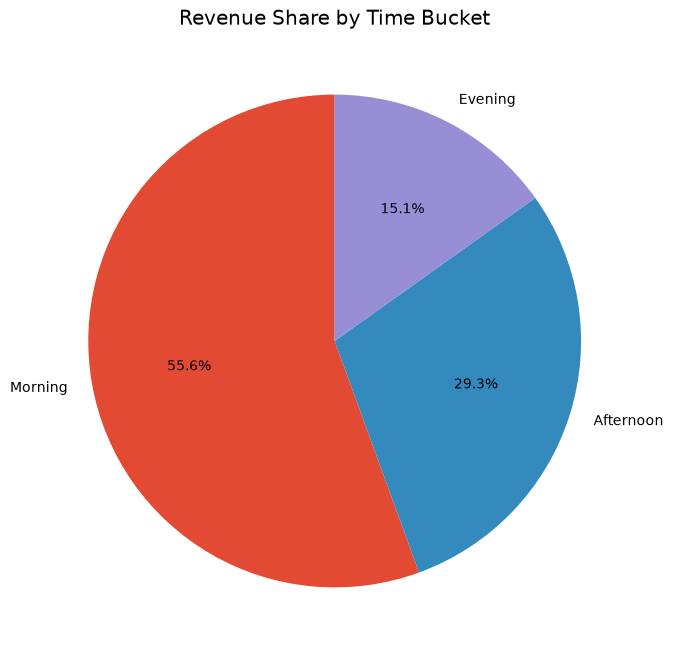

In [13]:
plt.figure(figsize=(8,8))

plt.pie(
    bucket,
    labels=bucket.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Share by Time Bucket")

plt.show()

In [14]:
ranking = (
    df.groupby("store_location")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

ranking

store_location
Hell's Kitchen     236511.17
Astoria            232243.91
Lower Manhattan    230057.25
Name: Revenue, dtype: float64

In [15]:
ranking_product = (
    df.groupby("product_type")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

ranking_product.head(20)

product_type
Barista Espresso         91406.20
Brewed Chai tea          77081.95
Hot chocolate            72416.00
Gourmet brewed coffee    70034.60
Brewed Black tea         47932.00
Brewed herbal tea        47539.50
Premium brewed coffee    38781.15
Organic brewed coffee    37746.50
Scone                    36866.12
Drip coffee              31984.00
Pastry                   25655.99
Brewed Green tea         23852.50
Biscotti                 19793.53
Premium Beans            14583.50
Organic Beans             8509.50
Housewares                7444.00
Gourmet Beans             6798.00
Clothing                  6163.00
Regular syrup             6084.80
Espresso Beans            5560.25
Name: Revenue, dtype: float64

In [16]:
print("="*60)
print("BUSINESS RECOMMENDATIONS")
print("="*60)

print()

print("1. Increase staff during the peak sales hour.")

print()

print("2. Keep additional inventory for high-revenue products.")

print()

print("3. Promote low-performing products using discounts.")

print()

print("4. Review operational strategy for the lowest-performing store.")

print()

print("5. Focus marketing campaigns on the highest revenue product category.")

print()

print("6. Schedule maintenance during low-demand hours.")

print()

print("7. Monitor hourly sales trends regularly to optimize staffing.")

print()

print("8. Ensure popular coffee products remain in stock during busy hours.")

BUSINESS RECOMMENDATIONS

1. Increase staff during the peak sales hour.

2. Keep additional inventory for high-revenue products.

3. Promote low-performing products using discounts.

4. Review operational strategy for the lowest-performing store.

5. Focus marketing campaigns on the highest revenue product category.

6. Schedule maintenance during low-demand hours.

7. Monitor hourly sales trends regularly to optimize staffing.

8. Ensure popular coffee products remain in stock during busy hours.


In [17]:
print("="*70)
print("EXECUTIVE SUMMARY")
print("="*70)

print(f"""
• Total Revenue Generated : ${df['Revenue'].sum():,.2f}

• Total Transactions : {df['transaction_id'].count():,}

• Average Order Value : ${df['Revenue'].mean():.2f}

• Best Store : {best_store}

• Highest Revenue Category : {category.idxmax()}

• Peak Sales Hour : {peak}:00

• Lowest Sales Hour : {slow}:00

The analysis shows clear hourly demand differences across the day.
Management should allocate staff according to peak hours,
maintain sufficient inventory for top-selling products,
and develop promotional strategies for lower-performing products.
""")

EXECUTIVE SUMMARY

• Total Revenue Generated : $698,812.33

• Total Transactions : 149,116

• Average Order Value : $4.69

• Best Store : Hell's Kitchen

• Highest Revenue Category : Coffee

• Peak Sales Hour : 10:00

• Lowest Sales Hour : 20:00

The analysis shows clear hourly demand differences across the day.
Management should allocate staff according to peak hours,
maintain sufficient inventory for top-selling products,
and develop promotional strategies for lower-performing products.

